# Clase 2 – Modelo KNN

## Objetivo
Aplicar el algoritmo K-Nearest Neighbors (KNN) para resolver un problema de clasificación agrícola, 
comprendiendo en profundidad cómo se preparan los datos, cómo se construyen las variables objetivo 
y cómo se valida correctamente el modelo mediante métricas, cross-validation y análisis de overfitting.

# Importancia de la validación

## Un modelo no es útil solo porque "acierta" en los datos de entrenamiento. Debemos responder:
## ¿Generaliza bien?
## ¿Es estable?
## ¿Está sobreajustado?

# Aquí entran:
## Métricas de evaluación
## Cross-validation
## Análisis de overfitting

In [2]:
#Archivo: Dataset_agro_rd_validado.csv
#Contexto: Produccion agricola en la republica dominicana
#Objetivo: Predecir la produccion agricola basada en diferentes factores
import pandas as pd

#cargar los datos
df = pd.read_csv('dataset_agro_rd_validado.csv')

#vista de los datos
df.head()

,Año,Mes,Región,Clima,Producto,Preparación_Suelo,Área_Sembrada_Tareas,Unidad_Medida,Producción_Total,Precio_Unitario
0,2021,4,Sur,Semiárido,Tayota,Invernadero,53,Unidades,241805.97,35.28
1,2024,2,Este,Tropical de Sabana,Tomate de Ensalada,Invernadero,312,Libras,468588.22,34.46
2,2023,11,Este,Tropical de Sabana,Cebolla Roja,Corte y Quema,75,Quintales (QQ),811.44,2653.71
3,2024,11,Este,Tropical de Sabana,Ñame,Arado Mecanizado,174,Quintales (QQ),573.60,2672.60
4,2020,7,Norte,Templado,Tayota,Invernadero,110,Unidades,265287.76,49.53


In [3]:
#creacion de variable objetivo
df['Nivel_de_produccion'] = pd.qcut(df['Producción_Total'], q=3, labels=['Bajo', 'Medio', 'Alto'])
#df['Nivel_de_produccion'] = df['Producción_Total'], q=3, labels=['Bajo', 'Medio', 'Alto']


#vista de los datos
df.head()

,Año,Mes,Región,Clima,Producto,Preparación_Suelo,Área_Sembrada_Tareas,Unidad_Medida,Producción_Total,Precio_Unitario,Nivel_de_produccion
0,2021,4,Sur,Semiárido,Tayota,Invernadero,53,Unidades,241805.97,35.28,Alto
1,2024,2,Este,Tropical de Sabana,Tomate de Ensalada,Invernadero,312,Libras,468588.22,34.46,Alto
2,2023,11,Este,Tropical de Sabana,Cebolla Roja,Corte y Quema,75,Quintales (QQ),811.44,2653.71,Bajo
3,2024,11,Este,Tropical de Sabana,Ñame,Arado Mecanizado,174,Quintales (QQ),573.60,2672.60,Bajo
4,2020,7,Norte,Templado,Tayota,Invernadero,110,Unidades,265287.76,49.53,Alto


In [4]:
caracteristicas = ['Área_Sembrada_Tareas','Producción_Total','Precio_Unitario','Mes']

X = df[caracteristicas]
y = df['Nivel_de_produccion']

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
#Recordatorio esto es abstracto
from sklearn.metrics import classification_report, confusion_matrix
y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))

''' Tarea: utilizar y interpretar cada una de las siguientes metricas de evaluación.
Métrica	Interpretación
Accuracy	Exactitud global
Precision	Qué tan confiables son las predicciones
Recall	Qué tanto captura la clase real
F1-score
'''

[[5215    2   76]
 [   0 4714  635]
 [  53 1091 4214]]


' Tarea: utilizar y interpretar cada una de las siguientes metricas de evaluación.\nMétrica\tInterpretación\nAccuracy\tExactitud global\nPrecision\tQué tan confiables son las predicciones\nRecall\tQué tanto captura la clase real\nF1-score\n'

In [9]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(knn, X_scaled, y, cv=5)
print("Cross-validation scores:", score)
print("Promedio cross-validation score:", score.mean())

Cross-validation scores: [0.8825625 0.886125  0.8875625 0.8858125 0.8800625]
Promedio cross-validation score: 0.884425


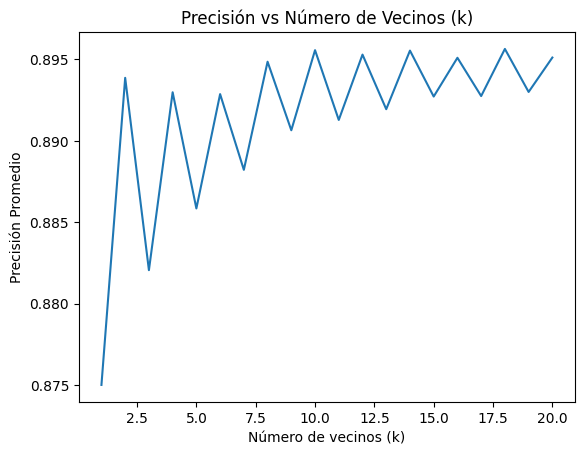

In [10]:
import matplotlib.pyplot as plt

k_values = range(1, 21)
Precision = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='precision_macro')
    Precision.append(scores.mean())

plt.plot(k_values, Precision)
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión Promedio')
plt.title('Precisión vs Número de Vecinos (k)')
plt.show()

In [11]:
#creracion de una nueva variable objetivo basada en la rentabilidad
df['rentabilidad'] = pd.qcut(
df['Producción_Total'] * df['Precio_Unitario'],
q=3,
labels=['Baja', 'Media', 'Alta']
)

X = df[caracteristicas]
y = df['rentabilidad']


X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Alto       0.99      0.99      0.99      5293
        Bajo       0.81      0.88      0.85      5349
       Medio       0.86      0.79      0.82      5358

    accuracy                           0.88     16000
   macro avg       0.89      0.88      0.88     16000
weighted avg       0.89      0.88      0.88     16000



## Cross-validation y Overfitting
Se usa cross-validation para verificar estabilidad del modelo.
Si accuracy entrenamiento >> test, hay overfitting.